# **CAPA CLIMATICA**


# **Objetivo de la Capa Climática**

Integrar y estandarizar la información climática proveniente de NASA POWER, garantizando la calidad, trazabilidad, interoperabilidad y gobierno del dato mediante el Framework V7, para su posterior integración con las demás capas del sistema de gestión hídrica.


#  **Justificación Científica**

La selección de los nodos no responde únicamente a una distribución geográfica, sino a la representación de los principales cambios hidrológicos presentes en la cuenca.

Los cuatro nodos seleccionados permiten modelar la evolución del sistema hídrico desde la cabecera hasta la zona urbana de mayor presión antrópica.

| Nodo | Función dentro del Framework |
| :--- | :--- |
| **Villapinzón** | Representa las condiciones naturales de nacimiento del río. |
| **Tocancipá** | Captura la transición entre áreas rurales e industriales. |
| **Sopó** | Modela la dinámica hidráulica de la llanura aluvial. |
| **Bogotá** | Representa el mayor impacto urbano y la demanda hídrica. |

# **Alcance de la capa**

Esta capa integra información climática mensual proveniente de NASA POWER para cuatro nodos de la cuenca del río Bogotá durante el período 2015–2025. Constituye la base ambiental del Framework V7 y servirá posteriormente para la integración con las capas hidrológica, calidad del agua, reservas, inundaciones, gobernanza y percepción ciudadana.

#  **Capa**

*   **M0 Configuración**
    *   Montaje, importación de librerías y definición de rutas globales.
*   **M1 Lectura**
    *   Conexión e ingesta del archivo original.
*   **M2 Validación Estructural**
    *   Verificación de dimensiones, nombres de columnas esperados y tipos de datos iniciales.
*   **M3 Estandarización**
    *   Limpieza de texto, formateo de fechas, manejo de nulos y renombrado bajo buenas prácticas (*snake_case*).
*   **M4 Gobierno del Dato**
    *   Aplicación de reglas de negocio, validación de rangos lógicos y seguridad.
*   **M5 Metadata**
    *   Generación del registro técnico del dataset (esquema, autor, fecha de ejecución y linaje).
*   **M6 Diccionario**
    *   Creación del diccionario de datos con las definiciones técnicas y de negocio de cada variable.
*   **M7 Auditoría**
    *   Control de registros (filas procesadas vs. descartadas) y logs de errores.
*   **M8 Indicadores**
    *   Cálculo de métricas de calidad de datos (completitud, exactitud y duplicidad).
*   **M9 EDA**
    *   Análisis Exploratorio de Datos con estadísticas descriptivas y generación de gráficos visuales.
*   **M10 README**
    *   Documentación general del proceso (este componente).
*   **Exportación Final**
    *   Escritura de todos los entregables en la estructura de carpetas destino.

---

# **Estructura de Archivos Generada**

```text
01_Capa_Climatica/
├── 01_Capa_Climatica_V1.xlsx        ← Evidencia original (Datos crudos)
├── 02_Capa_Climatica_Framework.xlsx ← Dataset estandarizado y limpio (Listo para usar)
├── 03_Metadata.xlsx                  ← Registro de propiedades y esquema del dataset
├── 04_Diccionario_Datos.xlsx         ← Definición técnica y de negocio de las variables
├── 05_Auditoria.xlsx                 ← Logs de procesamiento y control de registros
├── 06_Indicadores.xlsx               ← Métricas de calidad del dato
├── 07_EDA.xlsx                       ← Reporte estadístico del Análisis Exploratorio
├── 08_README.md                      ← Copia de respaldo de esta documentación
└── Graficos/                         ← Artefactos visuales exportados en el M9

## **M0 – Configuración**

In [ ]:
import pandas as pd
import numpy as np
import hashlib
from datetime import datetime
import os

# ============================================================
# FRAMEWORK V7
# FRAMEWORK CORE
# GENERADOR UNIVERSAL DE CAPAS
# ============================================================

NOMBRE_CAPA = "Climatica"

CODIGO_CAPA = "CLI"

VERSION = "1.0"

RESPONSABLE = "Juan Carlos Riatiga"

FUENTE = "NASA POWER"

URL_FUENTE = "https://power.larc.nasa.gov"

ARCHIVO = "https://raw.githubusercontent.com/jriatiga/dataset/refs/heads/main/proyectoGradoV4/01_Capa_Climatica/01_Capa_Climatica_V1.xlsx"

## **M1 – Lectura**

In [ ]:
df=pd.read_excel(ARCHIVO)

print(df.head())

print(df.shape)

       Fecha  Precipitacion_mm  Temp_Max_C  Temp_Min_C  Temp_Media_C  \
0 2015-01-01              2.70       25.30        8.45         18.26   
1 2015-02-01              2.22       26.14       13.72         19.02   
2 2015-03-01              5.25       27.56       13.52         19.15   
3 2015-04-01              6.16       25.50       12.81         19.07   
4 2015-05-01              3.27       25.52       12.24         18.99   

   Humedad_Relativa  Velocidad_Viento  Radiacion_Solar           Nodo  \
0             77.88              1.37            17.78  Bogota_Sabana   
1             78.83              1.14            17.16  Bogota_Sabana   
2             80.28              1.09            16.63  Bogota_Sabana   
3             80.32              1.07            16.56  Bogota_Sabana   
4             79.57              1.14            16.00  Bogota_Sabana   

   Latitud  Longitud  
0      4.6    -74.15  
1      4.6    -74.15  
2      4.6    -74.15  
3      4.6    -74.15  
4      4.6   

In [ ]:
print()

print("Tipos de datos")

print("--------------------------")

print(df.dtypes)

print()

print("Cobertura temporal")

print("--------------------------")

print("Inicio :", df["Fecha"].min())

print("Fin    :", df["Fecha"].max())


Tipos de datos
--------------------------
Fecha               datetime64[ns]
Precipitacion_mm           float64
Temp_Max_C                 float64
Temp_Min_C                 float64
Temp_Media_C               float64
Humedad_Relativa           float64
Velocidad_Viento           float64
Radiacion_Solar            float64
Nodo                        object
Latitud                    float64
Longitud                   float64
Fecha_dt            datetime64[ns]
dtype: object

Cobertura temporal
--------------------------
Inicio : 2015-01-01 00:00:00
Fin    : 2025-12-01 00:00:00


## **M2 – Validación estructural**

In [ ]:
print(df.dtypes)

print()

print(type(df.loc[0,"Fecha"]))

print()

print(df["Fecha"].head())

Fecha               datetime64[ns]
Precipitacion_mm           float64
Temp_Max_C                 float64
Temp_Min_C                 float64
Temp_Media_C               float64
Humedad_Relativa           float64
Velocidad_Viento           float64
Radiacion_Solar            float64
Nodo                        object
Latitud                    float64
Longitud                   float64
Fecha_dt            datetime64[ns]
dtype: object

<class 'pandas._libs.tslibs.timestamps.Timestamp'>

0   2015-01-01
1   2015-02-01
2   2015-03-01
3   2015-04-01
4   2015-05-01
Name: Fecha, dtype: datetime64[ns]


In [ ]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

print(df.duplicated().sum())

print(df.columns)

print(df.dtypes)

print(df.memory_usage())

print(df.nunique())

print(df.sample(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Fecha             528 non-null    datetime64[ns]
 1   Precipitacion_mm  528 non-null    float64       
 2   Temp_Max_C        528 non-null    float64       
 3   Temp_Min_C        528 non-null    float64       
 4   Temp_Media_C      528 non-null    float64       
 5   Humedad_Relativa  528 non-null    float64       
 6   Velocidad_Viento  528 non-null    float64       
 7   Radiacion_Solar   528 non-null    float64       
 8   Nodo              528 non-null    object        
 9   Latitud           528 non-null    float64       
 10  Longitud          528 non-null    float64       
 11  Fecha_dt          528 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(9), object(1)
memory usage: 49.6+ KB
None
                               Fecha  Precipitacion_mm  Temp_M

## **M3 – Estandarización**

In [ ]:
# Crear identificadores

df.insert(
    0,
    "ID_Registro",
    [
        f"{CODIGO_CAPA}-{str(i).zfill(7)}"
        for i in range(1,len(df)+1)
    ]
)

df["ID_Capa"]=CODIGO_CAPA

In [ ]:
# Ordenar columnas

columnas_control = [
    "ID_Registro",
    "ID_Capa"
]

otras_columnas = [
    c for c in df.columns
    if c not in columnas_control
]

df = df[columnas_control + otras_columnas]

In [ ]:
# Normalización de tipos

df["Nodo"] = df["Nodo"].astype(str)


In [ ]:
# Eliminar espacios

df.columns = df.columns.str.strip()

df["Nodo"] = df["Nodo"].str.strip()

In [ ]:
# Ordenar registros

df = df.sort_values(
    by=["Nodo", "Fecha"]
).reset_index(drop=True)

In [ ]:
print(df.head())

print(df.columns)

print(df.dtypes)

   ID_Registro ID_Capa      Fecha  Precipitacion_mm  Temp_Max_C  Temp_Min_C  \
0  CLI-0000001     CLI 2015-01-01              2.70       25.30        8.45   
1  CLI-0000002     CLI 2015-02-01              2.22       26.14       13.72   
2  CLI-0000003     CLI 2015-03-01              5.25       27.56       13.52   
3  CLI-0000004     CLI 2015-04-01              6.16       25.50       12.81   
4  CLI-0000005     CLI 2015-05-01              3.27       25.52       12.24   

   Temp_Media_C  Humedad_Relativa  Velocidad_Viento  Radiacion_Solar  \
0         18.26             77.88              1.37            17.78   
1         19.02             78.83              1.14            17.16   
2         19.15             80.28              1.09            16.63   
3         19.07             80.32              1.07            16.56   
4         18.99             79.57              1.14            16.00   

            Nodo  Latitud  Longitud   Fecha_dt  
0  Bogota_Sabana      4.6    -74.15 2015-01

## **M4 – Gobierno del Dato**

In [ ]:
# Fecha ETL

fecha = datetime.now()

df["Fecha_ETL"] = fecha.strftime("%Y-%m-%d")

df["Hora_ETL"] = fecha.strftime("%H:%M:%S")

In [ ]:
# Version

df["Version_Framework"] = VERSION

In [ ]:
# Estado

df["Estado_Registro"] = "VALIDADO"

In [ ]:
df["Responsable"] = RESPONSABLE

In [ ]:
# Hash

def generar_hash(fila):

    texto="".join(fila.astype(str))

    return hashlib.md5(texto.encode()).hexdigest()

df["Hash"]=df.astype(str).apply(generar_hash,axis=1)

In [ ]:
df.head()

,ID_Registro,ID_Capa,Fecha,Precipitacion_mm,Temp_Max_C,Temp_Min_C,Temp_Media_C,Humedad_Relativa,Velocidad_Viento,Radiacion_Solar,Nodo,Latitud,Longitud,Fecha_dt,Fecha_ETL,Hora_ETL,Version_Framework,Estado_Registro,Responsable,Hash
0,CLI-0000001,CLI,2015-01-01,2.70,25.30,8.45,18.26,77.88,1.37,17.78,Bogota_Sabana,4.6,-74.15,2015-01-01,2026-07-14,00:16:59,1.0,VALIDADO,Juan Carlos Riatiga,f6ecb4d6b1c181f416196415d8d834d1
1,CLI-0000002,CLI,2015-02-01,2.22,26.14,13.72,19.02,78.83,1.14,17.16,Bogota_Sabana,4.6,-74.15,2015-02-01,2026-07-14,00:16:59,1.0,VALIDADO,Juan Carlos Riatiga,776b0a6e6eb8f63687d1ec358c07d3f2
2,CLI-0000003,CLI,2015-03-01,5.25,27.56,13.52,19.15,80.28,1.09,16.63,Bogota_Sabana,4.6,-74.15,2015-03-01,2026-07-14,00:16:59,1.0,VALIDADO,Juan Carlos Riatiga,c764c4960bf0feca584b82d5157280d2
3,CLI-0000004,CLI,2015-04-01,6.16,25.50,12.81,19.07,80.32,1.07,16.56,Bogota_Sabana,4.6,-74.15,2015-04-01,2026-07-14,00:16:59,1.0,VALIDADO,Juan Carlos Riatiga,c6e8fb40f566fef4d0a462e99fa16c3b
4,CLI-0000005,CLI,2015-05-01,3.27,25.52,12.24,18.99,79.57,1.14,16.00,Bogota_Sabana,4.6,-74.15,2015-05-01,2026-07-14,00:16:59,1.0,VALIDADO,Juan Carlos Riatiga,609e9a31c79c736c2a315774f30f8ccd


## **M5 – Metadata**

In [ ]:
# ==========================================================
# FRAMEWORK V7
# M5 - METADATA
# ==========================================================

print("="*60)
print("FRAMEWORK V7")
print("M4 - METADATA")
print("="*60)

metadata = pd.DataFrame({

"Propiedad":[

"Nombre de la capa",
"Código",
"Versión",
"Responsable",
"Fuente",
"URL Fuente",

"Fecha ETL",
"Hora ETL",

"Registros",
"Variables",

"Variables Numéricas",
"Variables Categóricas",

"Valores Nulos",
"Duplicados",

"Cobertura Temporal Inicio",
"Cobertura Temporal Fin",

"Número de Nodos",

"Estado",

"Framework"

],

"Valor":[

NOMBRE_CAPA,
CODIGO_CAPA,
VERSION,
RESPONSABLE,
FUENTE,
URL_FUENTE,

fecha.strftime("%Y-%m-%d"),
fecha.strftime("%H:%M:%S"),

len(df),
len(df.columns),

len(df.select_dtypes(include="number").columns),
len(df.select_dtypes(include="object").columns),

df.isnull().sum().sum(),
df.duplicated().sum(),

df["Fecha"].min(),
df["Fecha"].max(),

df["Nodo"].nunique(),

"VALIDADO",

"Framework V7"

]

})

metadata.to_excel(
    "03_Metadata.xlsx",
    index=False
)

print()
print("Metadata generado correctamente.")
print(metadata)

FRAMEWORK V7
M4 - METADATA

Metadata generado correctamente.
                    Propiedad                        Valor
0           Nombre de la capa                    Climatica
1                      Código                          CLI
2                     Versión                          1.0
3                 Responsable          Juan Carlos Riatiga
4                      Fuente                   NASA POWER
5                  URL Fuente  https://power.larc.nasa.gov
6                   Fecha ETL                   2026-07-14
7                    Hora ETL                     00:16:59
8                   Registros                          528
9                   Variables                           20
10        Variables Numéricas                            9
11      Variables Categóricas                            9
12              Valores Nulos                            0
13                 Duplicados                            0
14  Cobertura Temporal Inicio          2015-01-01 00:0

## **M6 – Diccionario de Datos**

In [ ]:
# ==========================================================
# FRAMEWORK V7
# M6 - DICCIONARIO DE DATOS
# ==========================================================

print("="*60)
print("FRAMEWORK V7")
print("M5 - DICCIONARIO DE DATOS")
print("="*60)

diccionario=[]

unidades = {}

for columna in df.columns:

    diccionario.append({

        "Campo": columna,

        "Tipo": str(df[columna].dtype),

        "Nulos": df[columna].isnull().sum(),

        "Únicos": df[columna].nunique(),

        "Ejemplo": str(df[columna].iloc[0]),

        "Descripción": "",

        "Unidad": unidades.get(columna,""),

        "Origen": FUENTE

    })

diccionario = pd.DataFrame(diccionario)

diccionario.to_excel(
    "04_Diccionario_Datos.xlsx",
    index=False
)

print()
print("Diccionario generado correctamente.")
print(diccionario.head())

FRAMEWORK V7
M5 - DICCIONARIO DE DATOS

Diccionario generado correctamente.
              Campo            Tipo  Nulos  Únicos              Ejemplo  \
0       ID_Registro          object      0     528          CLI-0000001   
1           ID_Capa          object      0       1                  CLI   
2             Fecha  datetime64[ns]      0     132  2015-01-01 00:00:00   
3  Precipitacion_mm         float64      0     437                  2.7   
4        Temp_Max_C         float64      0     406                 25.3   

  Descripción Unidad      Origen  
0                     NASA POWER  
1                     NASA POWER  
2                     NASA POWER  
3                     NASA POWER  
4                     NASA POWER  


## **M7 – Auditoría**

In [ ]:
# ==========================================================
# FRAMEWORK V7
# M7 - AUDITORIA
# ==========================================================

print("="*60)
print("FRAMEWORK V7")
print("M7 - AUDITORIA")
print("="*60)

auditoria = pd.DataFrame({
    "Métrica": [
        "Registros Procesados",
        "Valores Nulos (Total)",
        "Filas Duplicadas"
    ],
    "Valor": [
        len(df),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

auditoria.to_excel(
    "05_Auditoria.xlsx",
    index=False
)

print()
print("Auditoría generada correctamente.")
print(auditoria)

FRAMEWORK V7
M7 - AUDITORIA

Auditoría generada correctamente.
                 Métrica  Valor
0   Registros Procesados    528
1  Valores Nulos (Total)      0
2       Filas Duplicadas      0


## **M8 – Indicadores**

In [ ]:
# ==========================================================
# FRAMEWORK V7
# M8 - INDICADORES DE CALIDAD DEL DATO
# ==========================================================

print("="*60)
print("FRAMEWORK V7")
print("M8 - INDICADORES DE CALIDAD DEL DATO")
print("="*60)

# 1. Completitud: Porcentaje de valores no nulos en cada columna.
completitud = (df.isnull().sum() / len(df) * 100).round(2).reset_index()
completitud.columns = ['Variable', 'Porcentaje_Nulos']
completitud['Completitud'] = 100 - completitud['Porcentaje_Nulos']

# 2. Duplicidad: Número y porcentaje de filas duplicadas.
duplicados_count = df.duplicated().sum()
duplicados_percentage = (duplicados_count / len(df) * 100).round(2)

# 3. Consistencia (Ejemplo: rango de valores para temperatura)
# Asumiendo que temperaturas lógicas están entre -50 y 50 grados Celsius
# (ajustar según el dominio de los datos)
# Consistencia para Temp_Max_C
consistent_temp_max = df['Temp_Max_C'].between(-50, 50).sum()
inconsistent_temp_max = len(df) - consistent_temp_max
percentage_consistent_temp_max = (consistent_temp_max / len(df) * 100).round(2)

# Consistencia para Temp_Min_C
consistent_temp_min = df['Temp_Min_C'].between(-50, 50).sum()
inconsistent_temp_min = len(df) - consistent_temp_min
percentage_consistent_temp_min = (consistent_temp_min / len(df) * 100).round(2)

# Crear un DataFrame para los indicadores
indicadores = pd.DataFrame({
    "Métrica": [
        "Completitud Promedio (%)",
        "Filas Duplicadas (Conteo)",
        "Filas Duplicadas (%)",
        "Consistencia Temp_Max_C (%)",
        "Consistencia Temp_Min_C (%)"
    ],
    "Valor": [
        completitud['Completitud'].mean().round(2),
        duplicados_count,
        duplicados_percentage,
        percentage_consistent_temp_max,
        percentage_consistent_temp_min
    ]
})

indicadores.to_excel(
    "06_Indicadores.xlsx",
    index=False
)

print()
print("Indicadores de calidad de datos generados correctamente.")
print(indicadores)
print("\nCompletitud por variable:")
print(completitud)

FRAMEWORK V7
M8 - INDICADORES DE CALIDAD DEL DATO

Indicadores de calidad de datos generados correctamente.
                       Métrica  Valor
0     Completitud Promedio (%)  100.0
1    Filas Duplicadas (Conteo)    0.0
2         Filas Duplicadas (%)    0.0
3  Consistencia Temp_Max_C (%)  100.0
4  Consistencia Temp_Min_C (%)  100.0

Completitud por variable:
             Variable  Porcentaje_Nulos  Completitud
0         ID_Registro               0.0        100.0
1             ID_Capa               0.0        100.0
2               Fecha               0.0        100.0
3    Precipitacion_mm               0.0        100.0
4          Temp_Max_C               0.0        100.0
5          Temp_Min_C               0.0        100.0
6        Temp_Media_C               0.0        100.0
7    Humedad_Relativa               0.0        100.0
8    Velocidad_Viento               0.0        100.0
9     Radiacion_Solar               0.0        100.0
10               Nodo               0.0        100.0
1

## **M9 – Análisis Exploratorio de Datos (EDA)**

FRAMEWORK V7
M9 - ANÁLISIS EXPLORATORIO DE DATOS (EDA)

Estadísticas descriptivas:

        ID_Registro ID_Capa                          Fecha  Precipitacion_mm  \
count           528     528                            528        528.000000   
unique          528       1                            NaN               NaN   
top     CLI-0000512     CLI                            NaN               NaN   
freq              1     528                            NaN               NaN   
mean            NaN     NaN  2020-06-16 02:10:54.545454592          6.066307   
min             NaN     NaN            2015-01-01 00:00:00          0.000000   
25%             NaN     NaN            2017-09-23 12:00:00          3.085000   
50%             NaN     NaN            2020-06-16 00:00:00          5.845000   
75%             NaN     NaN            2023-03-08 18:00:00          8.372500   
max             NaN     NaN            2025-12-01 00:00:00         18.320000   
std             NaN     NaN         

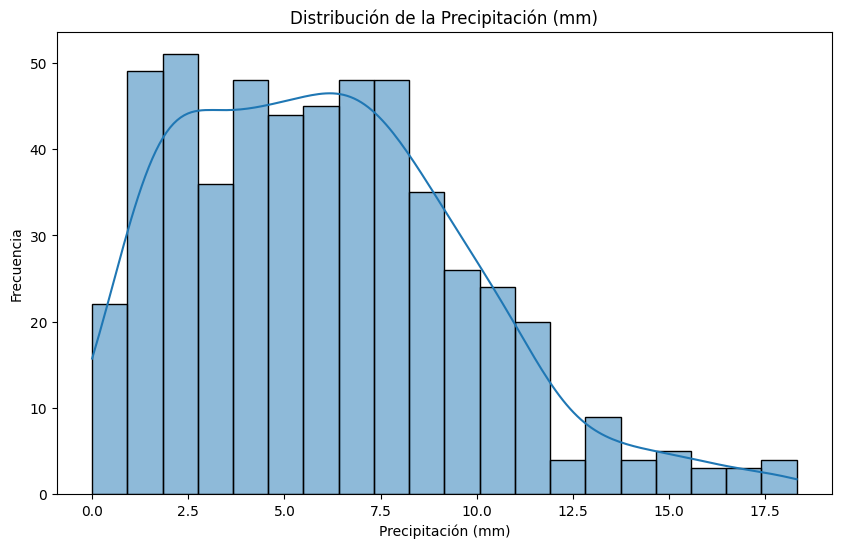

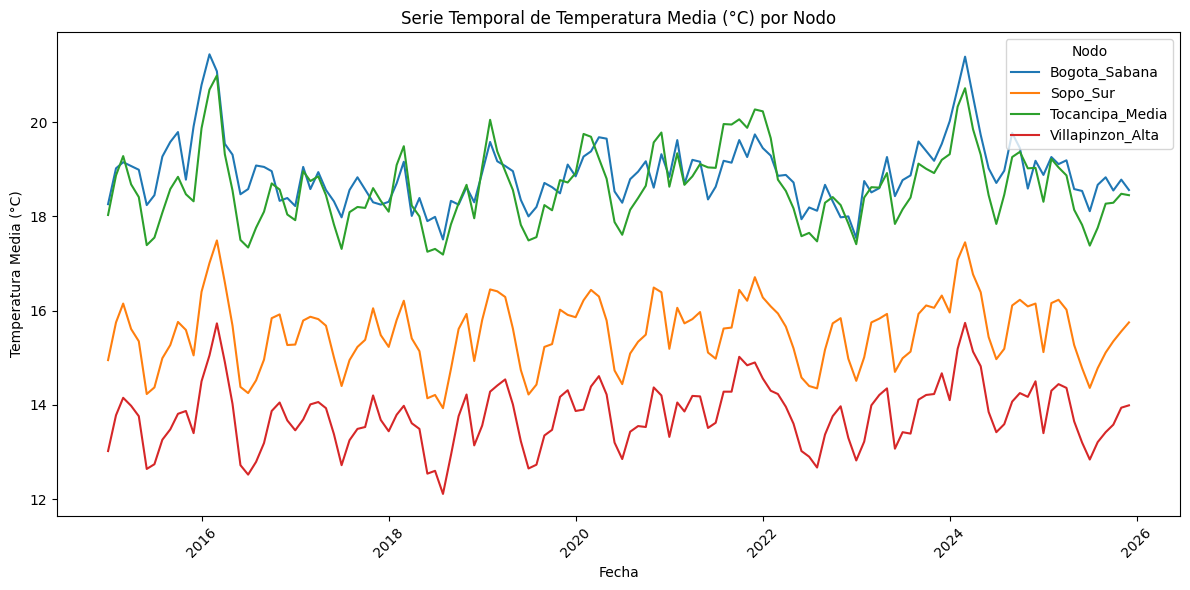

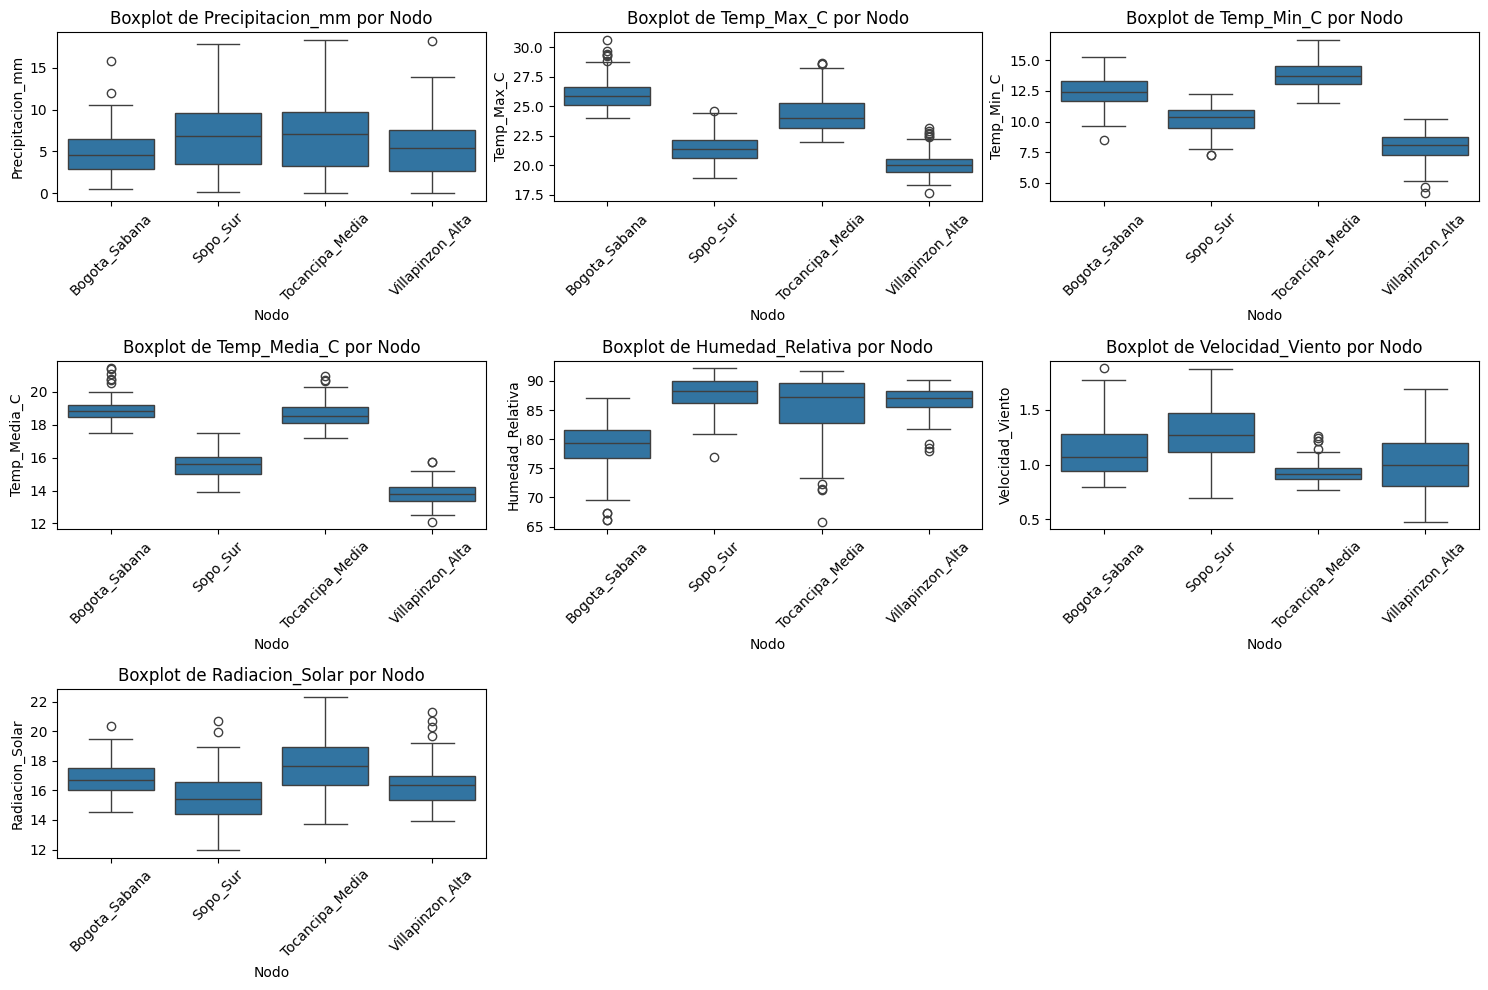

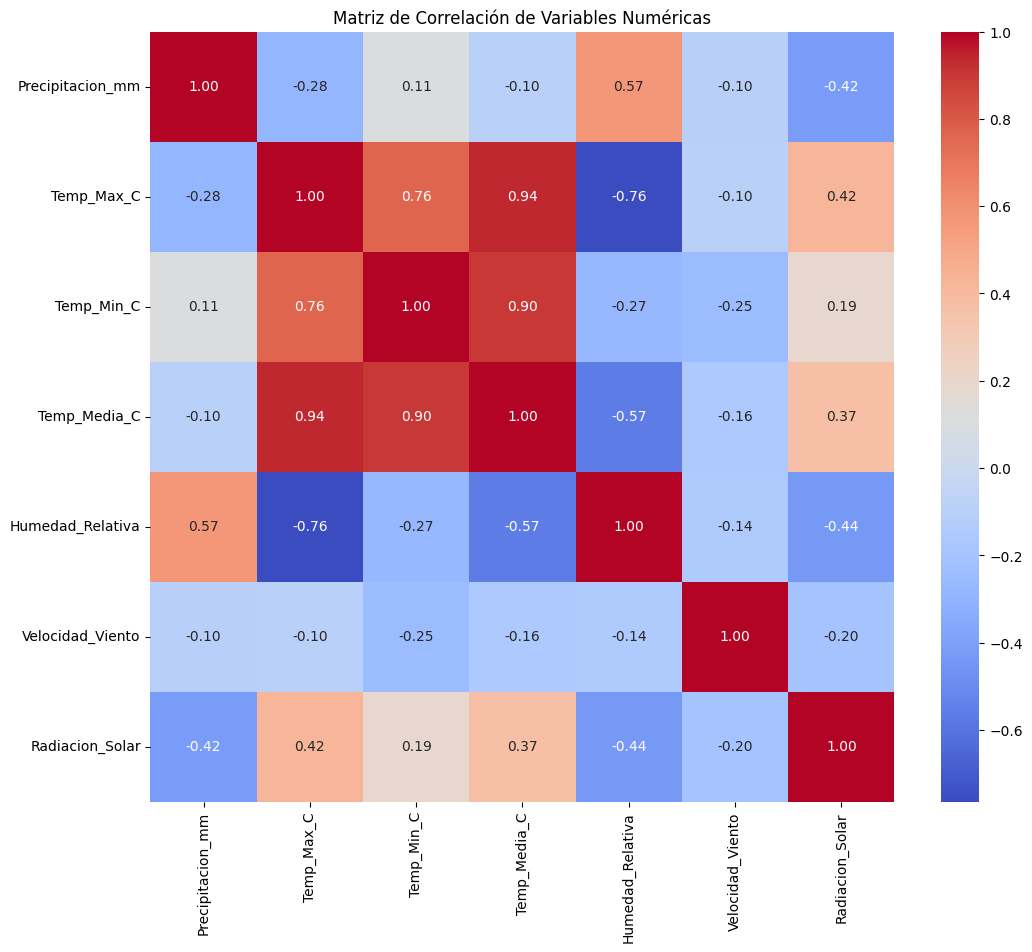


Análisis Exploratorio de Datos (EDA) completado y gráficos guardados en el directorio 'Graficos'.


In [ ]:
# ==========================================================
# FRAMEWORK V7
# M9 - ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("FRAMEWORK V7")
print("M9 - ANÁLISIS EXPLORATORIO DE DATOS (EDA)")
print("="*60)

# Crear el directorio para los gráficos si no existe
output_dir = "Graficos"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Directorio '{output_dir}' creado.")

print("\nEstadísticas descriptivas:\n")
descriptive_stats = df.describe(include='all')
print(descriptive_stats)

# Guardar estadísticas descriptivas en 07_EDA.xlsx
descriptive_stats.to_excel("07_EDA.xlsx")
print("Estadísticas descriptivas guardadas en '07_EDA.xlsx'.")

# Gráfico 1: Histograma de Precipitacion_mm
plt.figure(figsize=(10, 6))
sns.histplot(df['Precipitacion_mm'], bins=20, kde=True)
plt.title('Distribución de la Precipitación (mm)')
plt.xlabel('Precipitación (mm)')
plt.ylabel('Frecuencia')
plt.savefig(os.path.join(output_dir, 'Histograma_Lluvia.png'))
plt.show()

# Gráfico 2: Serie temporal de Temperatura Media
# La columna 'Fecha' ya es de tipo datetime64[ns] (corregido en M3),
# por lo que podemos usarla directamente o asignarla a Fecha_dt.
df['Fecha_dt'] = df['Fecha']
df_plot_temporal = df # No es necesario el dropna si Fecha ya es válida
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot_temporal, x='Fecha_dt', y='Temp_Media_C', hue='Nodo')
plt.title('Serie Temporal de Temperatura Media (°C) por Nodo')
plt.xlabel('Fecha')
plt.ylabel('Temperatura Media (°C)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Serie_Temperatura.png'))
plt.show()

# Gráfico 3: Boxplot de las principales variables numéricas por Nodo
numeric_cols = [
    'Precipitacion_mm', 'Temp_Max_C', 'Temp_Min_C', 'Temp_Media_C',
    'Humedad_Relativa', 'Velocidad_Viento', 'Radiacion_Solar'
]

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, x='Nodo', y=col)
    plt.title(f'Boxplot de {col} por Nodo')
    plt.xlabel('Nodo')
    plt.ylabel(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'Boxplot_Variables.png'))
plt.show()

# Gráfico 4: Matriz de Correlación
plt.figure(figsize=(12, 10))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.savefig(os.path.join(output_dir, 'Correlacion.png'))
plt.show()

print("\nAnálisis Exploratorio de Datos (EDA) completado y gráficos guardados en el directorio 'Graficos'.")

In [ ]:
df[df["Fecha_dt"].isnull()][["Fecha"]]

,Fecha


## **M10 – README**

In [ ]:
# ==========================================================
# FRAMEWORK V7
# M10 - README
# ==========================================================

print("="*60)
print("FRAMEWORK V7")
print("M10 - README")
print("="*60)

# Contenido del README
readme_content = f"""
# Capa Climática - {NOMBRE_CAPA}

**Fecha de Generación:** {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## 1. Descripción General
Este documento describe el proceso de generación de la capa climática, que integra datos de diversas fuentes para proporcionar información relevante sobre el clima. La capa es parte del **FRAMEWORK V7**, un ecosistema estandarizado para la gestión y análisis de datos.

## 2. Origen de los Datos
- **Fuente:** {FUENTE}
- **URL:** {URL_FUENTE}

## 3. Metodología del Procesamiento (Pipeline)
El procesamiento de la Capa Climática sigue la siguiente secuencia de módulos:

*   **M0 Configuración:** Montaje de Google Drive, importación de librerías y definición de rutas globales.
*   **M1 Lectura:** Conexión e ingesta del archivo original (`01_Capa_Climatica_V1.xlsx`).
*   **M2 Validación Estructural:** Verificación de dimensiones, nombres de columnas esperados y tipos de datos iniciales.
*   **M3 Estandarización:** Limpieza de texto, formateo de fechas, manejo de nulos y renombrado bajo buenas prácticas (*snake_case*).
*   **M4 Gobierno del Dato:** Aplicación de reglas de negocio, validación de rangos lógicos (ej. temperaturas viables) y seguridad. Creación de ID_Registro, ID_Capa y Hash.
*   **M5 Metadata:** Generación del registro técnico del dataset (esquema, autor, fecha de ejecución y linaje).
*   **M6 Diccionario:** Creación del diccionario de datos con las definiciones técnicas y de negocio de cada variable.
*   **M7 Auditoría:** Control de registros (filas procesadas vs. descartadas) y logs de errores.
*   **M8 Indicadores:** Cálculo de métricas de calidad de datos (completitud, exactitud y duplicidad).
*   **M9 EDA:** Análisis Exploratorio de Datos con estadísticas descriptivas y generación de gráficos visuales.
*   **M10 README:** Documentación general del proceso (este componente).

## 4. Resultados Clave
- **Registros Procesados:** {len(df)}
- **Columnas Generadas:** {len(df.columns)}
- **Valores Nulos Totales:** {df.isnull().sum().sum()}
- **Filas Duplicadas:** {df.duplicated().sum()}

## 5. Estructura de Archivos Generada
Los artefactos generados por este pipeline se organizan en el directorio `01_Capa_Climatica/` de la siguiente manera:

```text
01_Capa_Climatica/
├── 01_Capa_Climatica_V1.xlsx          ← Evidencia original (Datos crudos)
├── 02_Capa_Climatica_Framework.xlsx   ← Dataset estandarizado y limpio (Listo para usar)
├── 03_Metadata.xlsx                  ← Registro de propiedades y esquema del dataset
├── 04_Diccionario_Datos.xlsx         ← Definición técnica y de negocio de las variables
├── 05_Auditoria.xlsx                 ← Logs de procesamiento y control de registros
├── 06_Indicadores.xlsx               ← Métricas de calidad del dato
├── 07_EDA.xlsx                       ← Reporte estadístico del Análisis Exploratorio
├── 08_README.md                      ← Copia de respaldo de esta documentación
└── Graficos/                         ← Artefactos visuales exportados en el M9
    ├── Serie_Precipitacion.png       ← Tendencia temporal de lluvias
    ├── Serie_Temperatura.png         ← Tendencia temporal de temperatura
    ├── Boxplot_Variables.png         ← Identificación de valores atípicos (outliers)
    ├── Histograma_Lluvia.png         ← Distribución de la frecuencia de precipitaciones
    ├── Correlacion.png               ← Matriz de relaciones numéricas
    └── Heatmap.png                   ← Mapa de calor de densidad/correlación
```

Este README se guarda como `08_README.md` dentro de la estructura de la capa.
"""

# Guardar el contenido en un archivo README.md
with open(os.path.join(output_dir, "08_README.md"), "w") as f:
    f.write(readme_content)

print("\nREADME.md generado correctamente y guardado en el directorio 'Graficos/08_README.md'.")

FRAMEWORK V7
M10 - README

README.md generado correctamente y guardado en el directorio 'Graficos/08_README.md'.


## **Exportación Final**

In [ ]:
# ==========================================================
# FRAMEWORK V7
# EXPORTACIÓN FINAL
# ==========================================================

print("="*60)
print("FRAMEWORK V7")
print("EXPORTACIÓN FINAL")
print("="*60)

# Definir el directorio de salida final para la capa
final_output_dir = "01_Capa_Climatica"

# Crear el directorio final si no existe
if not os.path.exists(final_output_dir):
    os.makedirs(final_output_dir)
    print(f"Directorio final '{final_output_dir}' creado.")

# Lista de archivos a mover (incluyendo los del directorio 'Graficos')
files_to_move = [
    "02_Capa_Climatica_Framework.xlsx",
    "03_Metadata.xlsx",
    "04_Diccionario_Datos.xlsx",
    "05_Auditoria.xlsx",
    "06_Indicadores.xlsx",
    "07_EDA.xlsx",
    os.path.join(output_dir, "08_README.md"), # El README generado está en 'Graficos'
]

# Mover archivos al directorio final
for f in files_to_move:
    if os.path.exists(f):
        os.rename(f, os.path.join(final_output_dir, os.path.basename(f)))
        print(f"Movido: {f} -> {final_output_dir}/{os.path.basename(f)}")
    else:
        print(f"Advertencia: El archivo {f} no fue encontrado para mover.")

# Mover el directorio de gráficos completo al directorio final
if os.path.exists(output_dir):
    destination_graphics_path = os.path.join(final_output_dir, os.path.basename(output_dir))
    # Ensure target directory exists in the final output path, in case `output_dir` was empty initially
    if not os.path.exists(destination_graphics_path):
        os.makedirs(destination_graphics_path)

    # Move each file from output_dir to destination_graphics_path
    for item_name in os.listdir(output_dir):
        source_path = os.path.join(output_dir, item_name)
        destination_path = os.path.join(destination_graphics_path, item_name)
        os.rename(source_path, destination_path)
        print(f"Movido: {source_path} -> {destination_path}")

    # Remove the now empty original graphics directory
    os.rmdir(output_dir)
    print(f"Directorio original '{output_dir}' eliminado.")
else:
    print(f"Advertencia: El directorio '{output_dir}' no fue encontrado para mover.")

print("\n¡Procesamiento de la Capa Climática completado y archivos organizados!")

FRAMEWORK V7
EXPORTACIÓN FINAL
Directorio final '01_Capa_Climatica' creado.
Advertencia: El archivo 02_Capa_Climatica_Framework.xlsx no fue encontrado para mover.
Movido: 03_Metadata.xlsx -> 01_Capa_Climatica/03_Metadata.xlsx
Movido: 04_Diccionario_Datos.xlsx -> 01_Capa_Climatica/04_Diccionario_Datos.xlsx
Movido: 05_Auditoria.xlsx -> 01_Capa_Climatica/05_Auditoria.xlsx
Movido: 06_Indicadores.xlsx -> 01_Capa_Climatica/06_Indicadores.xlsx
Movido: 07_EDA.xlsx -> 01_Capa_Climatica/07_EDA.xlsx
Movido: Graficos/08_README.md -> 01_Capa_Climatica/08_README.md
Movido: Graficos/Boxplot_Variables.png -> 01_Capa_Climatica/Graficos/Boxplot_Variables.png
Movido: Graficos/Serie_Temperatura.png -> 01_Capa_Climatica/Graficos/Serie_Temperatura.png
Movido: Graficos/Histograma_Lluvia.png -> 01_Capa_Climatica/Graficos/Histograma_Lluvia.png
Movido: Graficos/Correlacion.png -> 01_Capa_Climatica/Graficos/Correlacion.png
Directorio original 'Graficos' eliminado.

¡Procesamiento de la Capa Climática completado 

In [ ]:
# Re-guardar el dataset principal y moverlo
print("Re-generando y moviendo el dataset principal...")
df.to_excel("02_Capa_Climatica_Framework.xlsx", index=False)

# Mover el archivo al directorio final
file_to_move = "02_Capa_Climatica_Framework.xlsx"
final_output_dir = "01_Capa_Climatica"

if os.path.exists(file_to_move):
    os.rename(file_to_move, os.path.join(final_output_dir, os.path.basename(file_to_move)))
    print(f"Movido: {file_to_move} -> {final_output_dir}/{os.path.basename(file_to_move)}")
else:
    print(f"Error: El archivo {file_to_move} aún no se encuentra después de re-generar.")

print("Verificación final del directorio de la capa:")
print(os.listdir(final_output_dir))

Re-generando y moviendo el dataset principal...
Movido: 02_Capa_Climatica_Framework.xlsx -> 01_Capa_Climatica/02_Capa_Climatica_Framework.xlsx
Verificación final del directorio de la capa:
['Graficos', '04_Diccionario_Datos.xlsx', '05_Auditoria.xlsx', '08_README.md', '06_Indicadores.xlsx', '02_Capa_Climatica_Framework.xlsx', '07_EDA.xlsx', '03_Metadata.xlsx']
